# Vibration Sensor

In [2]:
!pip install allantools -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis

import os, sys
from pathlib import Path

In [3]:
# ============================================================
# 2. Load data
# ============================================================

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 12, 'axes.labelsize': 10, 'lines.linewidth': 0.9,
})
CLR = {'raw': '#3498DB', 'trend': '#E74C3C', 'res': '#2C3E50', 'fit': '#E67E22'}


RUN_ID       = "011"
DATA_ROOT    = f"/content/drive/MyDrive/ProjectSHIELD_data/UNIT_0001_RUN_{RUN_ID}"
DATA_PATH    = f"{DATA_ROOT}/vibration.csv"
NOMINAL_HZ   = 1000.0


IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f"[warn] drive mount skipped: {e}")

print("=" * 64)
print(f"  Vibration Sensor Analysis  —  RUN_{RUN_ID}")
print("=" * 64)
print(f"  DATA_PATH = {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Data preview:")
display(df.head())

print("\nColumns:")
print(df.columns)

print("\nData shape:", df.shape)

Mounted at /content/drive
  Pressure Sensor Analysis  —  RUN_011
  DATA_PATH = /content/drive/MyDrive/ProjectSHIELD_data/UNIT_0001_RUN_011/vibration.csv
Data preview:


,timestamp_ms,value
0,4808,0.0
1,4809,0.0
2,4810,0.0
3,4811,0.0
4,4812,0.0



Columns:
Index(['timestamp_ms', 'value'], dtype='object')

Data shape: (53990716, 2)


In [4]:
# ============================================================
# 3. Select timestamp and vibration columns
# ============================================================

time_col = "timestamp_ms"
value_col = "value"

t = df[time_col].values
x = df[value_col].values

# Remove NaN values
valid_idx = ~np.isnan(x)
t = t[valid_idx]
x = x[valid_idx]

print("Number of valid samples:", len(x))

Number of valid samples: 53990716


In [5]:
# ============================================================
# 4. Convert timestamp to seconds
# ============================================================

# If timestamp is in milliseconds, convert to seconds.
# If already in seconds, set timestamp_unit = "s".

timestamp_unit = "ms"

if timestamp_unit == "ms":
    t_sec = (t - t[0]) / 1000.0
elif timestamp_unit == "us":
    t_sec = (t - t[0]) / 1_000_000.0
else:
    t_sec = t - t[0]

duration = t_sec[-1] - t_sec[0]
fs = 1000

print(f"Duration: {duration:.2f} seconds")

Duration: 54000.00 seconds


## Raw vibration signal

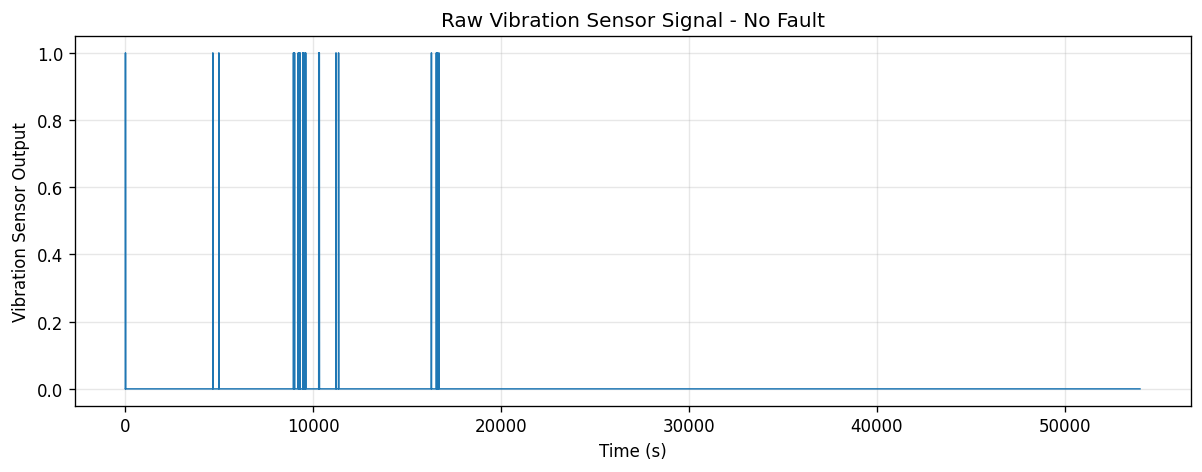

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(t_sec, x)
plt.xlabel("Time (s)")
plt.ylabel("Vibration Sensor Output")
plt.title("Raw Vibration Sensor Signal - No Fault")
plt.grid(True)
plt.show()

## Basic statistics

In [7]:
mean_x = np.mean(x)
std_x = np.std(x)
var_x = np.var(x)
rms_x = np.sqrt(np.mean(x**2))
ptp_x = np.ptp(x)
min_x = np.min(x)
max_x = np.max(x)
skew_x = skew(x)
kurt_x = kurtosis(x)

stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Standard Deviation",
        "Variance",
        "RMS",
        "Peak-to-Peak",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        mean_x,
        std_x,
        var_x,
        rms_x,
        ptp_x,
        min_x,
        max_x,
        skew_x,
        kurt_x
    ]
})

display(stats)

,Metric,Value
0,Mean,0.000119
1,Standard Deviation,0.010908
2,Variance,0.000119
3,RMS,0.010909
4,Peak-to-Peak,1.000000
5,Minimum,0.000000
6,Maximum,1.000000
7,Skewness,91.652738
8,Kurtosis,8398.224399


## Rolling / window-based RMS and STD

In [8]:
window_seconds = 5
window_size = int(fs * window_seconds)

window_times = []
rolling_mean = []
rolling_std = []
rolling_rms = []
rolling_ptp = []

for start in range(0, len(x) - window_size, window_size):
    end = start + window_size
    segment = x[start:end]

    window_times.append(t_sec[start])
    rolling_mean.append(np.mean(segment))
    rolling_std.append(np.std(segment))
    rolling_rms.append(np.sqrt(np.mean(segment**2)))
    rolling_ptp.append(np.ptp(segment))

window_df = pd.DataFrame({
    "time_s": window_times,
    "mean": rolling_mean,
    "std": rolling_std,
    "rms": rolling_rms,
    "peak_to_peak": rolling_ptp
})

display(window_df.head())

,time_s,mean,std,rms,peak_to_peak
0,0.0,0.0008,0.028273,0.028284,1.0
1,5.0,0.0000,0.000000,0.000000,0.0
2,10.0,0.0000,0.000000,0.000000,0.0
3,15.0,0.0000,0.000000,0.000000,0.0
4,20.0,0.0000,0.000000,0.000000,0.0


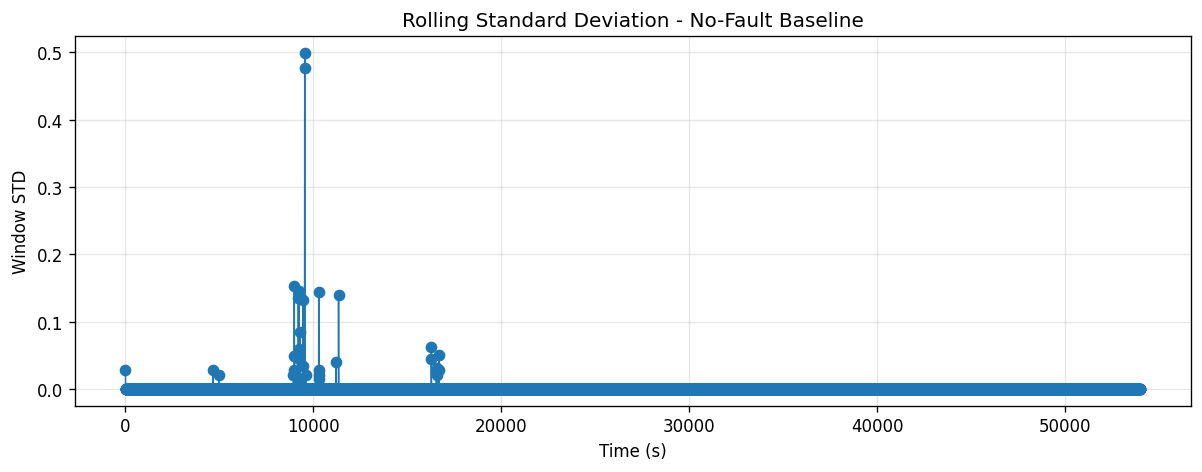

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(window_df["time_s"], window_df["std"], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Window STD")
plt.title("Rolling Standard Deviation - No-Fault Baseline")
plt.grid(True)
plt.show()

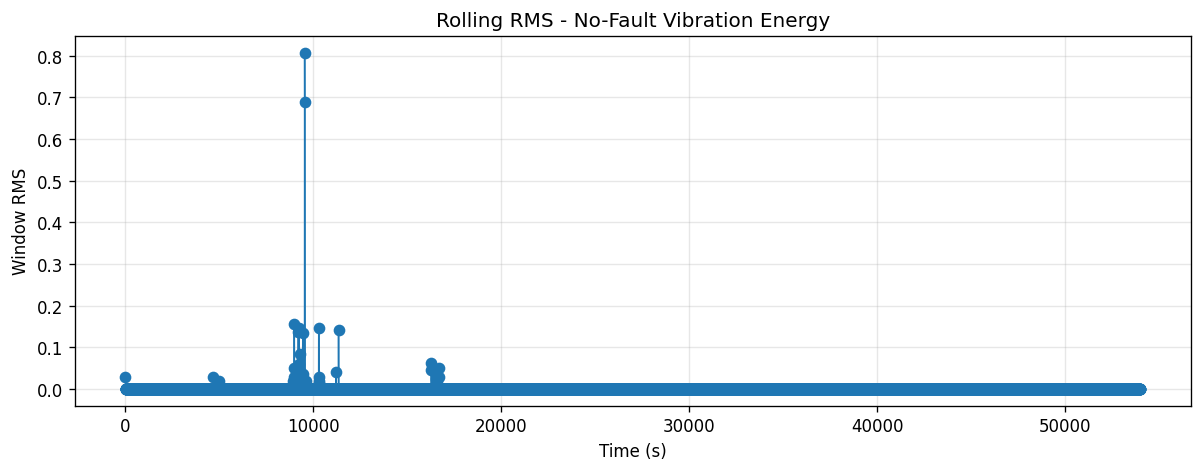

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(window_df["time_s"], window_df["rms"], marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Window RMS")
plt.title("Rolling RMS - No-Fault Vibration Energy")
plt.grid(True)
plt.show()

## Spike analysis

In [11]:
# Use 3-sigma threshold for nominal transient detection
threshold = 3 * std_x

spike_idx = np.where(np.abs(x - mean_x) > threshold)[0]

spike_count = len(spike_idx)
spike_rate = spike_count / len(x)

print("Spike count:", spike_count)
print("Spike rate:", spike_rate)

if spike_count > 0:
    print("Max spike amplitude from mean:", np.max(np.abs(x[spike_idx] - mean_x)))
else:
    print("No spikes detected using 3-sigma threshold.")

Spike count: 6425
Spike rate: 0.00011900194100037496
Max spike amplitude from mean: 0.9998809980589997


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


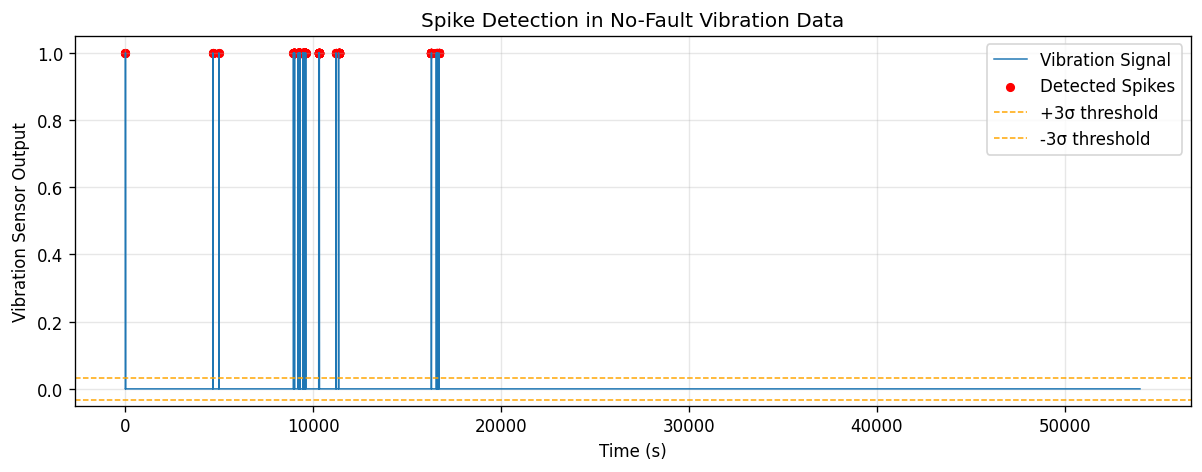

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(t_sec, x, label="Vibration Signal")
plt.scatter(t_sec[spike_idx], x[spike_idx], color="red", label="Detected Spikes", s=20)
plt.axhline(mean_x + threshold, color="orange", linestyle="--", label="+3σ threshold")
plt.axhline(mean_x - threshold, color="orange", linestyle="--", label="-3σ threshold")
plt.xlabel("Time (s)")
plt.ylabel("Vibration Sensor Output")
plt.title("Spike Detection in No-Fault Vibration Data")
plt.legend()
plt.grid(True)
plt.show()

## FFT frequency analysis

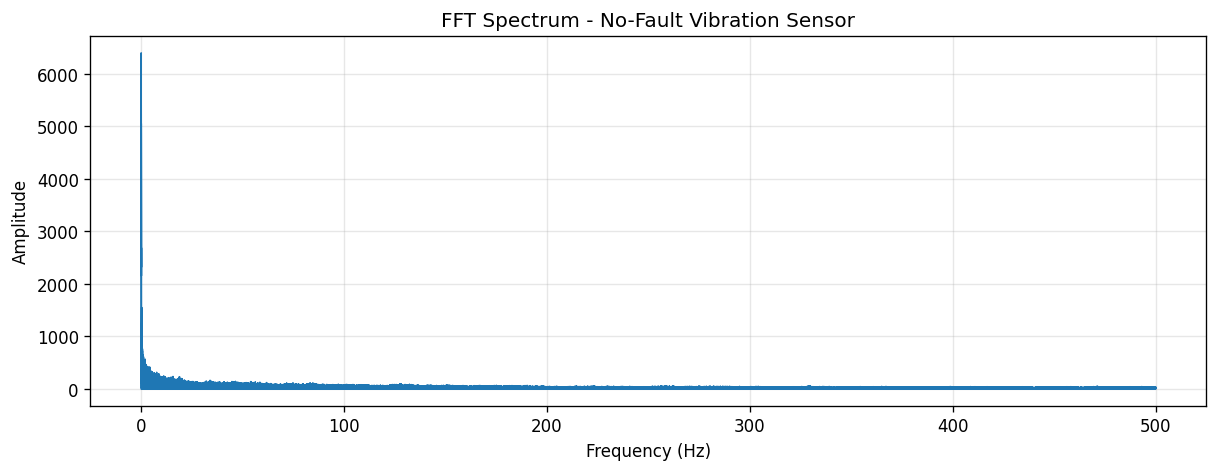

In [13]:
x_detrended = x - np.mean(x)

N = len(x_detrended)
yf = np.abs(rfft(x_detrended))
xf = rfftfreq(N, 1 / fs)

plt.figure(figsize=(12, 4))
plt.plot(xf, yf)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Spectrum - No-Fault Vibration Sensor")
plt.grid(True)
plt.show()

## PSD using Welch method

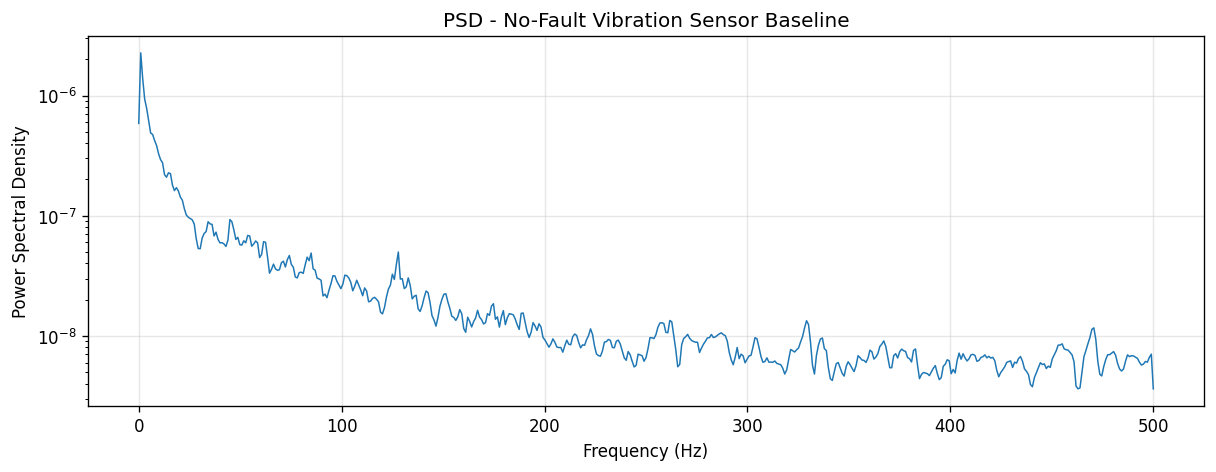

In [14]:
f, Pxx = welch(x_detrended, fs=fs, nperseg=min(1024, len(x_detrended)))

plt.figure(figsize=(12, 4))
plt.semilogy(f, Pxx)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD - No-Fault Vibration Sensor Baseline")
plt.grid(True)
plt.show()